In [2]:
import sys
from pathlib import Path
import pandas as pd

print("Python:", sys.executable)

PROJECT_DIR = Path.cwd().parent
METADATA_DIR = PROJECT_DIR / "outputs" / "metadata"

FAIRFACE_METADATA_PATH = METADATA_DIR / "fairface_metadata.csv"

fairface_df = pd.read_csv(FAIRFACE_METADATA_PATH)

print("FairFace metadata loaded successfully.")
print("Rows:", len(fairface_df))
print("Columns:", list(fairface_df.columns))

print("\nRace distribution:")
print(fairface_df["race_name"].value_counts())

print("\nRace IDs:")
print(
    fairface_df[["race", "race_name"]]
    .drop_duplicates()
    .sort_values("race")
)

Python: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Scripts\python.exe
FairFace metadata loaded successfully.
Rows: 97698
Columns: ['age', 'gender', 'race', 'race_name', 'service_test']

Race distribution:
race_name
White              18612
Latino/Hispanic    14990
East Asian         13837
Indian             13835
Black              13789
Southeast Asian    12210
Middle Eastern     10425
Name: count, dtype: int64

Race IDs:
    race        race_name
0      0       East Asian
1      1           Indian
2      2            Black
5      3            White
6      4   Middle Eastern
12     5  Latino/Hispanic
16     6  Southeast Asian


In [3]:
from sklearn.model_selection import train_test_split

demo_train_df, demo_val_df = train_test_split(
    fairface_df,
    test_size=0.20,
    random_state=42,
    stratify=fairface_df["race"]
)

demo_train_df = demo_train_df.reset_index(drop=True)
demo_val_df = demo_val_df.reset_index(drop=True)

print("Total samples:", len(fairface_df))
print("Training samples:", len(demo_train_df))
print("Validation samples:", len(demo_val_df))

print("\nTraining distribution:")
print(demo_train_df["race_name"].value_counts())

print("\nValidation distribution:")
print(demo_val_df["race_name"].value_counts())

Total samples: 97698
Training samples: 78158
Validation samples: 19540

Training distribution:
race_name
White              14889
Latino/Hispanic    11992
East Asian         11070
Indian             11068
Black              11031
Southeast Asian     9768
Middle Eastern      8340
Name: count, dtype: int64

Validation distribution:
race_name
White              3723
Latino/Hispanic    2998
East Asian         2767
Indian             2767
Black              2758
Southeast Asian    2442
Middle Eastern     2085
Name: count, dtype: int64


In [4]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_fairface_image(image_bytes, label):
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(label, tf.int32)

    return image, label

print("FairFace image pipeline configuration created.")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

FairFace image pipeline configuration created.
Image size: (128, 128)
Batch size: 64


In [5]:
FAIRFACE_DIR = PROJECT_DIR / "data" / "demographic" / "FairFace" / "0.25"

parquet_files = sorted(FAIRFACE_DIR.glob("*.parquet"))

print("FairFace directory:", FAIRFACE_DIR)
print("Parquet files found:", len(parquet_files))

for file in parquet_files:
    print(file.name)

FairFace directory: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\demographic\FairFace\0.25
Parquet files found: 3
train-00000-of-00002-d405faba4f4b9b85.parquet
train-00001-of-00002-dd3cb68164727418.parquet
validation-00000-of-00001-951dbd63c8724ee1.parquet


In [6]:
import pandas as pd

sample_parquet = parquet_files[0]

sample_df = pd.read_parquet(sample_parquet)

print("File:", sample_parquet.name)
print("Shape:", sample_df.shape)
print("Columns:", list(sample_df.columns))

print("\nFirst row:")
print(sample_df.iloc[0])

print("\nImage field type:")
print(type(sample_df.iloc[0]["image"]))

File: train-00000-of-00002-d405faba4f4b9b85.parquet
Shape: (43372, 5)
Columns: ['image', 'age', 'gender', 'race', 'service_test']

First row:
image           {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
age                                                             6
gender                                                          0
race                                                            0
service_test                                                 True
Name: 0, dtype: object

Image field type:
<class 'dict'>


Image format: JPEG
Image size: (224, 224)
Image mode: RGB


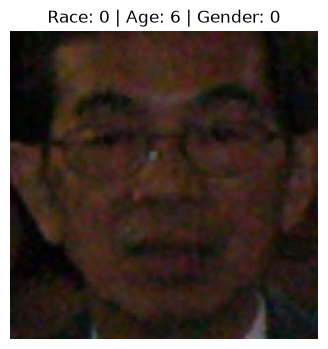

In [8]:
import io
from PIL import Image
import matplotlib.pyplot as plt

image_bytes = sample_df.iloc[0]["image"]["bytes"]

image = Image.open(io.BytesIO(image_bytes))

print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Race: {sample_df.iloc[0]['race']} | "
    f"Age: {sample_df.iloc[0]['age']} | "
    f"Gender: {sample_df.iloc[0]['gender']}"
)
plt.show()

In [9]:
# Prepare FairFace labels and image bytes from the first Parquet file

fairface_train_sample = sample_df.copy()

fairface_train_sample["label"] = fairface_train_sample["race"].astype(np.int32)

image_bytes_list = [
    item["bytes"]
    for item in fairface_train_sample["image"]
]

labels = fairface_train_sample["label"].to_numpy(dtype=np.int32)

print("Images:", len(image_bytes_list))
print("Labels:", len(labels))
print("Unique labels:", sorted(np.unique(labels).tolist()))
print("Image bytes type:", type(image_bytes_list[0]))

Images: 43372
Labels: 43372
Unique labels: [0, 1, 2, 3, 4, 5, 6]
Image bytes type: <class 'bytes'>


In [10]:
# Create TensorFlow dataset from FairFace image bytes

fairface_ds = tf.data.Dataset.from_tensor_slices(
    (image_bytes_list, labels)
)

fairface_ds = fairface_ds.map(
    load_fairface_image,
    num_parallel_calls=AUTOTUNE
)

fairface_ds = fairface_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("FairFace TensorFlow dataset created successfully.")

FairFace TensorFlow dataset created successfully.


In [11]:
images, labels_batch = next(iter(fairface_ds))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

print("Labels shape:", labels_batch.shape)
print("Labels dtype:", labels_batch.dtype)
print("Sample labels:", labels_batch[:20].numpy())

Images shape: (64, 128, 128, 3)
Images dtype: <dtype: 'float32'>
Pixel range: 0.0 to 1.0
Labels shape: (64,)
Labels dtype: <dtype: 'int32'>
Sample labels: [0 1 2 1 1 3 4 1 3 4 0 0 5 1 1 3 6 6 2 6]


In [12]:
from tensorflow.keras import layers, models

# ============================================
# Demographic Classification Model
# ============================================

demo_model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classification head
    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),
    layers.Dropout(0.40),

    # 7 FairFace demographic classes
    layers.Dense(
        7,
        activation="softmax"
    )
])

# Display model architecture
demo_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,695 (17.50 MB)

 Trainable params: 4,585,735 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# Load both FairFace training Parquet files

train_parquet_files = sorted(
    FAIRFACE_DIR.glob("train-*.parquet")
)

print("Training Parquet files found:", len(train_parquet_files))

fairface_train_1 = pd.read_parquet(train_parquet_files[0])
fairface_train_2 = pd.read_parquet(train_parquet_files[1])

fairface_train_full = pd.concat(
    [fairface_train_1, fairface_train_2],
    ignore_index=True
)

print("\nTraining data loaded.")
print("Total training rows:", len(fairface_train_full))
print("Columns:", list(fairface_train_full.columns))

print("\nRace distribution:")
print(fairface_train_full["race"].value_counts().sort_index())

Training Parquet files found: 2

Training data loaded.
Total training rows: 86744
Columns: ['image', 'age', 'gender', 'race', 'service_test']

Race distribution:
race
0    12287
1    12319
2    12233
3    16527
4     9216
5    13367
6    10795
Name: count, dtype: int64


In [14]:
# Inspect service_test distribution in the complete FairFace training data

print("service_test distribution:")
print(fairface_train_full["service_test"].value_counts(dropna=False))

print("\nservice_test + race distribution:")
print(
    fairface_train_full
    .groupby(["service_test", "race"])
    .size()
    .unstack(fill_value=0)
)

service_test distribution:
service_test
False    46492
True     40252
Name: count, dtype: int64

service_test + race distribution:
race             0     1     2      3     4     5     6
service_test                                           
False         6515  6565  6479  10750  3502  7611  5070
True          5772  5754  5754   5777  5714  5756  5725


In [15]:
# Load the official FairFace validation Parquet file

validation_parquet_files = sorted(
    FAIRFACE_DIR.glob("validation-*.parquet")
)

print("Validation Parquet files found:", len(validation_parquet_files))

fairface_val_full = pd.read_parquet(validation_parquet_files[0])

print("\nValidation data loaded.")
print("Total validation rows:", len(fairface_val_full))
print("Columns:", list(fairface_val_full.columns))

print("\nRace distribution:")
print(
    fairface_val_full["race"]
    .value_counts()
    .sort_index()
)

Validation Parquet files found: 1

Validation data loaded.
Total validation rows: 10954
Columns: ['image', 'age', 'gender', 'race', 'service_test']

Race distribution:
race
0    1550
1    1516
2    1556
3    2085
4    1209
5    1623
6    1415
Name: count, dtype: int64


In [16]:
# Prepare complete FairFace training and validation data

train_image_bytes = [
    item["bytes"]
    for item in fairface_train_full["image"]
]

train_labels = fairface_train_full["race"].to_numpy(dtype=np.int32)

val_image_bytes = [
    item["bytes"]
    for item in fairface_val_full["image"]
]

val_labels = fairface_val_full["race"].to_numpy(dtype=np.int32)

print("Training images:", len(train_image_bytes))
print("Training labels:", len(train_labels))

print("Validation images:", len(val_image_bytes))
print("Validation labels:", len(val_labels))

print("Training label classes:", sorted(np.unique(train_labels).tolist()))
print("Validation label classes:", sorted(np.unique(val_labels).tolist()))

Training images: 86744
Training labels: 86744
Validation images: 10954
Validation labels: 10954
Training label classes: [0, 1, 2, 3, 4, 5, 6]
Validation label classes: [0, 1, 2, 3, 4, 5, 6]


In [17]:
# Create final FairFace TensorFlow datasets

demo_train_ds = tf.data.Dataset.from_tensor_slices(
    (train_image_bytes, train_labels)
)

demo_val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_bytes, val_labels)
)

# Shuffle training data
demo_train_ds = demo_train_ds.shuffle(
    buffer_size=len(train_image_bytes),
    seed=42,
    reshuffle_each_iteration=True
)

# Decode, resize, normalize
demo_train_ds = demo_train_ds.map(
    load_fairface_image,
    num_parallel_calls=AUTOTUNE
)

demo_val_ds = demo_val_ds.map(
    load_fairface_image,
    num_parallel_calls=AUTOTUNE
)

# Batch and prefetch
demo_train_ds = demo_train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
demo_val_ds = demo_val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Final FairFace datasets created successfully.")
print("Training samples:", len(train_image_bytes))
print("Validation samples:", len(val_image_bytes))
print("Batch size:", BATCH_SIZE)

Final FairFace datasets created successfully.
Training samples: 86744
Validation samples: 10954
Batch size: 64


In [18]:
images, labels_batch = next(iter(demo_train_ds))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print(
    "Pixel range:",
    float(tf.reduce_min(images)),
    "to",
    float(tf.reduce_max(images))
)

print("Labels shape:", labels_batch.shape)
print("Labels dtype:", labels_batch.dtype)
print("Sample labels:", labels_batch[:20].numpy())

print("\nFinal FairFace dataset verification successful.")

Images shape: (64, 128, 128, 3)
Images dtype: <dtype: 'float32'>
Pixel range: 0.0 to 1.0
Labels shape: (64,)
Labels dtype: <dtype: 'int32'>
Sample labels: [2 5 3 6 6 3 0 0 5 2 5 1 2 3 4 6 0 3 0 5]

Final FairFace dataset verification successful.


In [19]:
from pathlib import Path
import tensorflow as tf

# ============================================
# Demographic Model Callbacks
# ============================================

DEMO_MODEL_PATH = PROJECT_DIR / "models" / "demographic_model_best.keras"

demo_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=DEMO_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Demographic callbacks created.")
print("Model will be saved to:", DEMO_MODEL_PATH)

Demographic callbacks created.
Model will be saved to: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras


In [20]:
# ============================================
# Compile Demographic Model
# ============================================

demo_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Demographic model compiled successfully.")

Demographic model compiled successfully.


In [21]:
# ============================================
# Train Demographic Model
# ============================================

DEMO_EPOCHS = 15

print("Starting demographic model training...")
print("Epochs:", DEMO_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image size:", IMG_SIZE)
print("Training images:", len(train_image_bytes))
print("Validation images:", len(val_image_bytes))

demo_history = demo_model.fit(
    demo_train_ds,
    validation_data=demo_val_ds,
    epochs=DEMO_EPOCHS,
    callbacks=demo_callbacks,
    verbose=1
)

print("\nDemographic model training completed.")

Starting demographic model training...
Epochs: 15
Batch size: 64
Image size: (128, 128)
Training images: 86744
Validation images: 10954
Epoch 1/15


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1356/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2672 - loss: 1.8586
Epoch 1: val_accuracy improved from None to 0.32874, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 2505s 2s/step - accuracy: 0.2672 - loss: 1.8586 - val_accuracy: 0.3287 - val_loss: 1.9067 - learning_rate: 1.0000e-04
Epoch 2/15
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3627 - loss: 1.6398
Epoch 2: val_accuracy improved from 0.32874 to 0.43591, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 2604s 2s/step - accuracy: 0.3627 - loss: 1.6398 - val_accuracy: 0.

In [22]:
DEMO_MODEL_PATH = PROJECT_DIR / "models" / "demographic_model_best.keras"

demo_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=DEMO_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Demographic model callbacks created.")
print("Best model path:", DEMO_MODEL_PATH)

Demographic model callbacks created.
Best model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras


In [ ]:
DEMO_EPOCHS = 20

print("==========================================")
print("STARTING FAST DEMOGRAPHIC MODEL TRAINING")
print("==========================================")
print()

print("Epochs:", DEMO_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image size:", IMG_SIZE)
print("Training images:", len(train_image_bytes))
print("Validation images:", len(val_image_bytes))
print()

demo_history = demo_model.fit(
    demo_train_ds,
    validation_data=demo_val_ds,
    epochs=DEMO_EPOCHS,
    callbacks=demo_callbacks,
    verbose=1
)

print()
print("==========================================")
print("DEMOGRAPHIC TRAINING COMPLETED")
print("==========================================")

STARTING FAST DEMOGRAPHIC MODEL TRAINING

Epochs: 20
Batch size: 64
Image size: (128, 128)
Training images: 86744
Validation images: 10954

Epoch 1/20
  33/1356 ━━━━━━━━━━━━━━━━━━━━ 49:21 2s/step - accuracy: 0.5668 - loss: 1.1168

In [ ]:
from pathlib import Path
import tensorflow as tf

DEMO_MODEL_PATH = Path(
    r"C:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras"
)

best_demo_model = tf.keras.models.load_model(DEMO_MODEL_PATH)

print("Demographic model loaded successfully.")
print("Model path:", DEMO_MODEL_PATH)
print("Model input:", best_demo_model.input_shape)
print("Model output:", best_demo_model.output_shape)

Demographic model loaded successfully.
Model path: C:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\demographic_model_best.keras
Model input: (None, 128, 128, 3)
Model output: (None, 7)


: 

: 

: 

: 

: 

In [ ]:
print("Current kernel is ready.")
print("Next we will rebuild the FairFace validation dataset for evaluation.")


Current kernel is ready.
Next we will rebuild the FairFace validation dataset for evaluation.


: 

: 

: 

: 

: 

In [ ]:
from pathlib import Path
import pandas as pd
import tensorflow as tf

# Project paths
PROJECT_DIR = Path(r"C:\Users\hasibul shaikh\Documents\Nationality_Detection_AI")
FAIRFACE_DIR = PROJECT_DIR / "data" / "demographic" / "FairFace" / "0.25"

# Find the official validation parquet
val_parquet = list(FAIRFACE_DIR.glob("validation-*.parquet"))

print("Validation parquet files found:", len(val_parquet))

# Load official FairFace validation data
fairface_val_full = pd.read_parquet(val_parquet[0])

print("Validation records:", len(fairface_val_full))
print("Columns:", list(fairface_val_full.columns))
print("Race labels:", sorted(fairface_val_full["race"].unique()))

Validation parquet files found: 1
Validation records: 10954
Columns: ['image', 'age', 'gender', 'race', 'service_test']
Race labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


: 

: 

: 

: 

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Extract image bytes and labels
val_image_bytes = fairface_val_full["image"].apply(
    lambda x: x["bytes"]
).tolist()

val_labels = fairface_val_full["race"].astype("int32").to_numpy()

def load_fairface_image(image_bytes, label):
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.int32)
    return image, label

# Create validation dataset
demo_val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_bytes, val_labels)
)

demo_val_ds = (
    demo_val_ds
    .map(load_fairface_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Validation dataset created.")
print("Validation images:", len(val_image_bytes))
print("Validation labels:", len(val_labels))

Validation dataset created.
Validation images: 10954
Validation labels: 10954


: 

: 

: 

: 

: 

In [ ]:
# Evaluate the saved demographic model
demo_val_loss, demo_val_accuracy = best_demo_model.evaluate(
    demo_val_ds,
    verbose=1
)

print("\nDemographic Model Evaluation")
print("Validation Loss:", round(demo_val_loss, 4))
print("Validation Accuracy:", round(demo_val_accuracy * 100, 2), "%")

NameError: name 'best_demo_model' is not defined

: 

: 

: 

: 

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("Dress-colour detection libraries loaded.")

Dress-colour detection libraries loaded.


: 

: 

: 

: 

In [ ]:
def detect_dress_color(image):
    """
    Estimate dominant clothing/dress color from the central-lower
    region of a person image.

    Returns:
        color_name: estimated dominant color
        confidence: percentage of pixels supporting that color
    """

    # Convert RGB image to OpenCV BGR
    if isinstance(image, Image.Image):
        image = np.array(image)

    if image is None or image.size == 0:
        return "Unknown", 0.0

    if len(image.shape) != 3 or image.shape[2] != 3:
        return "Unknown", 0.0

    # Central/lower body region
    h, w = image.shape[:2]

    y1 = int(h * 0.35)
    y2 = int(h * 0.90)
    x1 = int(w * 0.20)
    x2 = int(w * 0.80)

    body = image[y1:y2, x1:x2]

    if body.size == 0:
        return "Unknown", 0.0

    # RGB → HSV
    hsv = cv2.cvtColor(body, cv2.COLOR_RGB2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Ignore very dark / very low-saturation pixels
    valid = (V > 40) & (S > 35)

    total_valid = np.sum(valid)

    if total_valid == 0:
        return "Black/Dark", 100.0

    color_masks = {
        "Red": ((H < 10) | (H >= 170)) & valid,
        "Orange": (H >= 10) & (H < 22) & valid,
        "Yellow": (H >= 22) & (H < 35) & valid,
        "Green": (H >= 35) & (H < 85) & valid,
        "Blue": (H >= 85) & (H < 130) & valid,
        "Purple": (H >= 130) & (H < 160) & valid,
        "Pink": (H >= 160) & (H < 170) & valid,
    }

    percentages = {}

    for color, mask in color_masks.items():
        percentages[color] = (np.sum(mask) / total_valid) * 100

    dominant_color = max(percentages, key=percentages.get)
    dominant_percentage = percentages[dominant_color]

    # Check neutral colors separately
    gray_mask = (S <= 35) & (V >= 60) & (V < 200)
    white_mask = (S <= 35) & (V >= 200)
    black_mask = V < 60

    gray_percentage = (np.sum(gray_mask) / body.shape[0] / body.shape[1]) * 100
    white_percentage = (np.sum(white_mask) / body.shape[0] / body.shape[1]) * 100
    black_percentage = (np.sum(black_mask) / body.shape[0] / body.shape[1]) * 100

    if black_percentage > 45:
        dominant_color = "Black"
        dominant_percentage = black_percentage
    elif white_percentage > 45:
        dominant_color = "White"
        dominant_percentage = white_percentage
    elif gray_percentage > 45:
        dominant_color = "Grey"
        dominant_percentage = gray_percentage

    return dominant_color, round(float(dominant_percentage), 2)


print("Dress-colour detector created successfully.")

Dress-colour detector created successfully.


: 

: 

: 

: 

In [ ]:
# Test dress-colour detector on one FairFace validation image

sample_image_bytes = val_image_bytes[0]

# Decode JPEG
sample_image = tf.io.decode_jpeg(
    sample_image_bytes,
    channels=3
).numpy()

# Detect dress colour
dress_color, dress_confidence = detect_dress_color(sample_image)

print("Dress colour:", dress_color)
print("Colour percentage:", dress_confidence, "%")

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"{dress_color} ({dress_confidence}%)")
plt.show()

NameError: name 'val_image_bytes' is not defined

: 

: 

: 

: 

In [ ]:
def detect_dress_color(image):
    """
    Estimate clothing colour only when a sufficient clothing/body
    region is visible. Otherwise return Unknown.
    """

    if isinstance(image, Image.Image):
        image = np.array(image)

    if image is None or image.size == 0:
        return "Unknown", 0.0

    if len(image.shape) != 3 or image.shape[2] != 3:
        return "Unknown", 0.0

    h, w = image.shape[:2]

    # Clothing region: lower 50% of image.
    # Avoid the face/head area.
    y1 = int(h * 0.45)
    y2 = int(h * 0.95)
    x1 = int(w * 0.15)
    x2 = int(w * 0.85)

    body = image[y1:y2, x1:x2]

    if body.size == 0:
        return "Unknown", 0.0

    # Convert to HSV
    hsv = cv2.cvtColor(body, cv2.COLOR_RGB2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Ignore very dark/very low-information pixels
    valid = (V > 35)

    total_pixels = body.shape[0] * body.shape[1]
    valid_pixels = np.sum(valid)

    # Not enough useful clothing pixels
    if valid_pixels < total_pixels * 0.20:
        return "Unknown", 0.0

    color_masks = {
        "Red": ((H < 10) | (H >= 170)) & (S > 50) & valid,
        "Orange": (H >= 10) & (H < 22) & (S > 50) & valid,
        "Yellow": (H >= 22) & (H < 35) & (S > 50) & valid,
        "Green": (H >= 35) & (H < 85) & (S > 50) & valid,
        "Blue": (H >= 85) & (H < 130) & (S > 50) & valid,
        "Purple": (H >= 130) & (H < 160) & (S > 50) & valid,
        "Pink": (H >= 160) & (H < 170) & (S > 50) & valid,
    }

    percentages = {}

    for color, mask in color_masks.items():
        percentages[color] = (
            np.sum(mask) / valid_pixels
        ) * 100

    dominant_color = max(percentages, key=percentages.get)
    dominant_percentage = percentages[dominant_color]

    # Require meaningful colour coverage
    if dominant_percentage < 20:
        # Check neutral colours
        gray_mask = (S <= 40) & (V >= 60) & (V < 200) & valid
        white_mask = (S <= 40) & (V >= 200) & valid
        black_mask = (V < 60)

        gray_pct = np.sum(gray_mask) / total_pixels * 100
        white_pct = np.sum(white_mask) / total_pixels * 100
        black_pct = np.sum(black_mask) / total_pixels * 100

        if black_pct > 35:
            return "Black", round(float(black_pct), 2)

        if white_pct > 35:
            return "White", round(float(white_pct), 2)

        if gray_pct > 35:
            return "Grey", round(float(gray_pct), 2)

        return "Unknown", round(float(dominant_percentage), 2)

    return dominant_color, round(float(dominant_percentage), 2)


print("Improved dress-colour detector created.")

Improved dress-colour detector created.


: 

: 

: 

: 

In [ ]:
dress_color, dress_confidence = detect_dress_color(sample_image)

print("Dress colour:", dress_color)
print("Colour percentage:", dress_confidence, "%")

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Dress Colour: {dress_color} ({dress_confidence}%)")
plt.show()

NameError: name 'sample_image' is not defined

: 

: 

: 

: 

In [ ]:
try:
    from ultralytics import YOLO
    print("Ultralytics YOLO is available.")
except ImportError:
    print("Ultralytics YOLO is NOT installed.")

Ultralytics YOLO is available.


: 

: 

: 

: 

In [ ]:
from ultralytics import YOLO

print("Ultralytics YOLO is available.")

Ultralytics YOLO is available.


: 

: 

: 

: 

: 

In [ ]:
from ultralytics import YOLO

YOLO_MODEL_PATH = PROJECT_DIR / "models" / "yolo11n.pt"

# Download/load YOLO if the model file is not already present
if YOLO_MODEL_PATH.exists():
    person_model = YOLO(str(YOLO_MODEL_PATH))
else:
    person_model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully.")

YOLO model loaded successfully.


: 

: 

: 

: 

Persons detected: 1


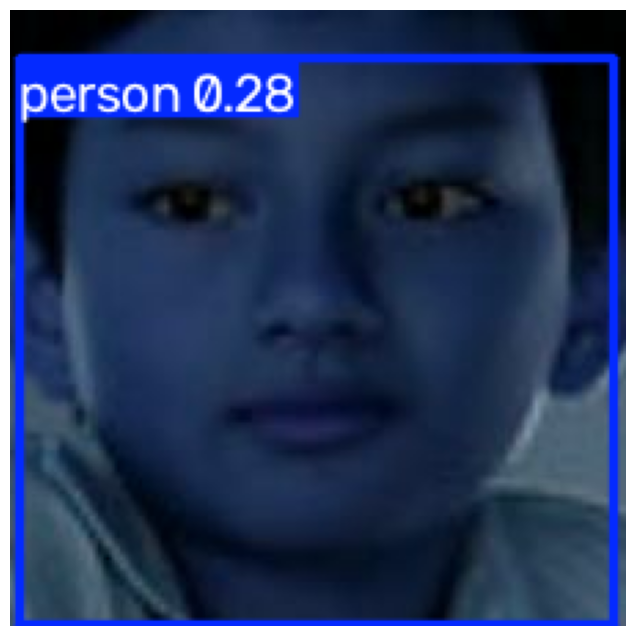

: 

: 

: 

: 

In [ ]:
# Test YOLO person detection on the sample image

results = person_model.predict(
    source=sample_image,
    conf=0.25,
    verbose=False
)

result = results[0]

person_count = 0

for box in result.boxes:
    class_id = int(box.cls[0])
    
    # COCO class 0 = person
    if class_id == 0:
        person_count += 1

print("Persons detected:", person_count)

# Display YOLO result
annotated_image = result.plot()

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
def detect_dress_color_yolo(image, model, conf=0.35):
    """
    Detect a person with YOLO and estimate clothing colour
    from the lower portion of the person's bounding box.
    """

    if isinstance(image, Image.Image):
        image = np.array(image)

    if image is None or image.size == 0:
        return "Not visible", 0.0

    results = model.predict(
        source=image,
        conf=conf,
        verbose=False
    )

    result = results[0]

    person_boxes = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        # COCO class 0 = person
        if class_id == 0:
            x1, y1, x2, y2 = map(
                int,
                box.xyxy[0].cpu().numpy()
            )

            person_boxes.append(
                (confidence, x1, y1, x2, y2)
            )

    if not person_boxes:
        return "Not visible", 0.0

    # Use the most confident person
    person_boxes.sort(reverse=True)
    _, x1, y1, x2, y2 = person_boxes[0]

    h, w = image.shape[:2]

    # Keep coordinates inside image
    x1 = max(0, min(x1, w - 1))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h - 1))
    y2 = max(0, min(y2, h))

    person_height = y2 - y1

    # If person is too small, clothing cannot be estimated reliably
    if person_height < 100:
        return "Not visible", 0.0

    # Lower 55% of person bounding box
    clothing_y1 = int(y1 + person_height * 0.45)
    clothing_y2 = y2

    clothing = image[clothing_y1:clothing_y2, x1:x2]

    if clothing.size == 0:
        return "Not visible", 0.0

    hsv = cv2.cvtColor(clothing, cv2.COLOR_RGB2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Require sufficiently saturated/visible pixels
    valid = V > 40
    valid_pixels = np.sum(valid)

    if valid_pixels < clothing.size / 3:
        return "Not visible", 0.0

    color_masks = {
        "Red": ((H < 10) | (H >= 170)) & (S > 60) & valid,
        "Orange": (H >= 10) & (H < 22) & (S > 60) & valid,
        "Yellow": (H >= 22) & (H < 35) & (S > 60) & valid,
        "Green": (H >= 35) & (H < 85) & (S > 60) & valid,
        "Blue": (H >= 85) & (H < 130) & (S > 60) & valid,
        "Purple": (H >= 130) & (H < 160) & (S > 60) & valid,
        "Pink": (H >= 160) & (H < 170) & (S > 60) & valid,
    }

    percentages = {
        color: (np.sum(mask) / valid_pixels) * 100
        for color, mask in color_masks.items()
    }

    dominant_color = max(percentages, key=percentages.get)
    dominant_percentage = percentages[dominant_color]

    # Neutral colours
    gray_mask = (S < 40) & (V >= 60) & (V < 200)
    white_mask = (S < 40) & (V >= 200)
    black_mask = V < 60

    gray_pct = np.sum(gray_mask) / clothing.size * 100
    white_pct = np.sum(white_mask) / clothing.size * 100
    black_pct = np.sum(black_mask) / clothing.size * 100

    if black_pct > 40:
        return "Black", round(float(black_pct), 2)

    if white_pct > 40:
        return "White", round(float(white_pct), 2)

    if gray_pct > 40:
        return "Grey", round(float(gray_pct), 2)

    # Don't make a colour claim if evidence is weak
    if dominant_percentage < 25:
        return "Not visible", round(float(dominant_percentage), 2)

    return dominant_color, round(float(dominant_percentage), 2)


print("YOLO-based dress-colour detector created successfully.")

YOLO-based dress-colour detector created successfully.


: 

: 

: 

: 

In [ ]:
dress_color, dress_confidence = detect_dress_color_yolo(
    sample_image,
    person_model
)

print("Dress colour:", dress_color)
print("Confidence:", dress_confidence, "%")

Dress colour: Not visible
Confidence: 0.0 %


: 

: 

: 

: 

Dress colour: Not visible
Confidence: 0.0 %


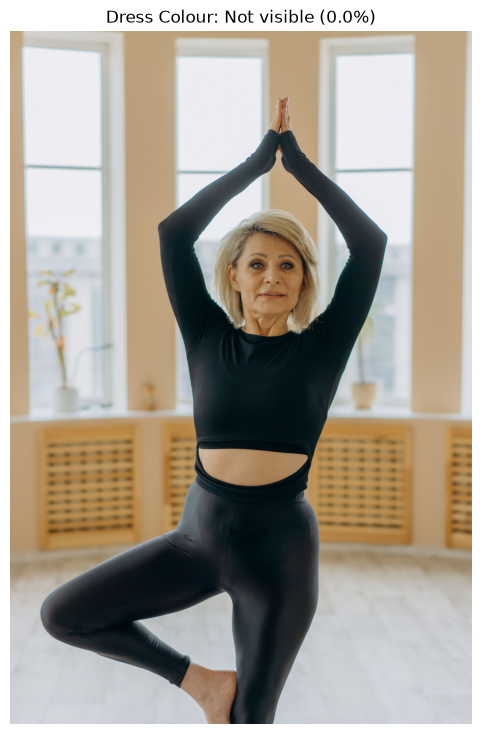

: 

: 

: 

: 

In [ ]:
# Test YOLO dress-colour detection on the full-body image

test_dress_path = PROJECT_DIR / "data" / "pexels-mikhail-nilov-7500436.jpg"

test_dress_image = np.array(
    Image.open(test_dress_path).convert("RGB")
)

dress_color, dress_confidence = detect_dress_color_yolo(
    test_dress_image,
    person_model
)

print("Dress colour:", dress_color)
print("Confidence:", dress_confidence, "%")

# Display image
plt.figure(figsize=(7, 9))
plt.imshow(test_dress_image)
plt.axis("off")
plt.title(f"Dress Colour: {dress_color} ({dress_confidence}%)")
plt.show()

In [ ]:
def detect_dress_color_yolo(image, model, conf=0.35):
    """
    YOLO person detection + clothing colour estimation.

    Improved handling for black/dark clothing under different lighting.
    """

    if isinstance(image, Image.Image):
        image = np.array(image)

    if image is None or image.size == 0:
        return "Not visible", 0.0

    if len(image.shape) != 3 or image.shape[2] != 3:
        return "Not visible", 0.0

    results = model.predict(
        source=image,
        conf=conf,
        verbose=False
    )

    result = results[0]

    person_boxes = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        if class_id == 0:
            x1, y1, x2, y2 = map(
                int,
                box.xyxy[0].cpu().numpy()
            )

            person_boxes.append(
                (confidence, x1, y1, x2, y2)
            )

    if not person_boxes:
        return "Not visible", 0.0

    # Highest-confidence person
    person_boxes.sort(reverse=True)
    _, x1, y1, x2, y2 = person_boxes[0]

    h, w = image.shape[:2]

    x1 = max(0, min(x1, w - 1))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h - 1))
    y2 = max(0, min(y2, h))

    person_height = y2 - y1
    person_width = x2 - x1

    if person_height < 80 or person_width < 40:
        return "Not visible", 0.0

    # Lower body/clothing region
    clothing_y1 = int(y1 + person_height * 0.40)
    clothing_y2 = y2

    clothing = image[clothing_y1:clothing_y2, x1:x2]

    if clothing.size == 0:
        return "Not visible", 0.0

    hsv = cv2.cvtColor(clothing, cv2.COLOR_RGB2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    total_pixels = clothing.shape[0] * clothing.shape[1]

    # ---- DARK / BLACK ----
    # More tolerant of lighting than the previous V < 60 rule.
    dark_mask = (V < 105) & (S > 20)

    dark_percentage = (
        np.sum(dark_mask) / total_pixels
    ) * 100

    # If a large part of clothing is dark, classify as black.
    if dark_percentage >= 40:
        return "Black", round(float(dark_percentage), 2)

    # ---- WHITE / GREY ----
    white_mask = (S < 40) & (V >= 180)

    gray_mask = (
        (S < 45) &
        (V >= 80) &
        (V < 180)
    )

    white_percentage = (
        np.sum(white_mask) / total_pixels
    ) * 100

    gray_percentage = (
        np.sum(gray_mask) / total_pixels
    ) * 100

    if white_percentage >= 40:
        return "White", round(float(white_percentage), 2)

    if gray_percentage >= 40:
        return "Grey", round(float(gray_percentage), 2)

    # ---- COLOURED CLOTHING ----
    valid = V > 40
    valid_pixels = np.sum(valid)

    if valid_pixels == 0:
        return "Not visible", 0.0

    color_masks = {
        "Red": ((H < 10) | (H >= 170)) & (S > 60) & valid,
        "Orange": (H >= 10) & (H < 22) & (S > 60) & valid,
        "Yellow": (H >= 22) & (H < 35) & (S > 60) & valid,
        "Green": (H >= 35) & (H < 85) & (S > 60) & valid,
        "Blue": (H >= 85) & (H < 130) & (S > 60) & valid,
        "Purple": (H >= 130) & (H < 160) & (S > 60) & valid,
        "Pink": (H >= 160) & (H < 170) & (S > 60) & valid,
    }

    percentages = {
        color: (np.sum(mask) / valid_pixels) * 100
        for color, mask in color_masks.items()
    }

    dominant_color = max(percentages, key=percentages.get)
    dominant_percentage = percentages[dominant_color]

    if dominant_percentage < 25:
        return "Not visible", round(float(dominant_percentage), 2)

    return dominant_color, round(float(dominant_percentage), 2)


print("Improved dark-clothing detector created successfully.")

Improved dark-clothing detector created successfully.


: 

: 

: 

: 

Dress colour: Orange
Confidence: 41.7 %


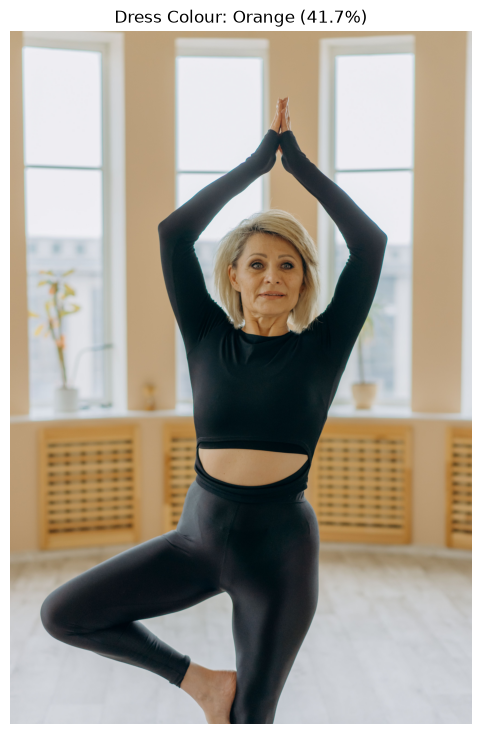

: 

: 

: 

: 

In [ ]:
dress_color, dress_confidence = detect_dress_color_yolo(
    test_dress_image,
    person_model
)

print("Dress colour:", dress_color)
print("Confidence:", dress_confidence, "%")

plt.figure(figsize=(7, 9))
plt.imshow(test_dress_image)
plt.axis("off")
plt.title(f"Dress Colour: {dress_color} ({dress_confidence}%)")
plt.show()

In [ ]:
from ultralytics import YOLO

SEG_MODEL_PATH = PROJECT_DIR / "models" / "yolo11n-seg.pt"

if SEG_MODEL_PATH.exists():
    person_seg_model = YOLO(str(SEG_MODEL_PATH))
else:
    person_seg_model = YOLO("yolo11n-seg.pt")

print("YOLO segmentation model loaded successfully.")

YOLO segmentation model loaded successfully.


: 

: 

: 

: 

Persons detected: 1
Segmentation masks available: True


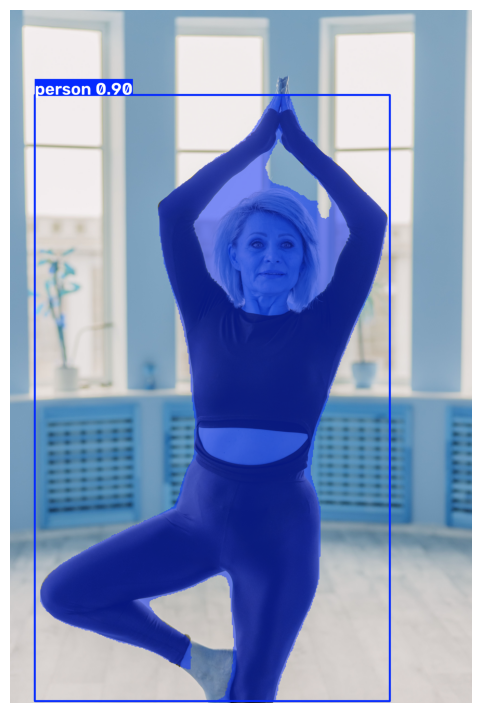

: 

: 

: 

: 

In [ ]:
# Test YOLO segmentation on the full-body image

seg_results = person_seg_model.predict(
    source=test_dress_image,
    conf=0.25,
    verbose=False
)

seg_result = seg_results[0]

person_count = 0

if seg_result.masks is not None:
    for i, box in enumerate(seg_result.boxes):
        class_id = int(box.cls[0])

        # COCO class 0 = person
        if class_id == 0:
            person_count += 1

print("Persons detected:", person_count)
print("Segmentation masks available:", seg_result.masks is not None)

# Display segmentation result
seg_annotated = seg_result.plot()

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(seg_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
def detect_dress_color_segmentation(image, model, conf=0.25):
    """
    Detect the person using YOLO segmentation and estimate
    clothing colour from the lower portion of the person mask.
    """

    if isinstance(image, Image.Image):
        image = np.array(image)

    if image is None or image.size == 0:
        return "Not visible", 0.0

    results = model.predict(
        source=image,
        conf=conf,
        verbose=False
    )

    result = results[0]

    if result.masks is None:
        return "Not visible", 0.0

    person_indices = []

    for i, box in enumerate(result.boxes):
        class_id = int(box.cls[0])

        # COCO class 0 = person
        if class_id == 0:
            person_indices.append(i)

    if not person_indices:
        return "Not visible", 0.0

    # Select the largest detected person
    best_index = max(
        person_indices,
        key=lambda i: float(result.boxes[i].conf[0])
    )

    # Get segmentation mask
    mask = result.masks.data[best_index].cpu().numpy()

    h, w = image.shape[:2]

    # Resize mask to original image size
    mask = cv2.resize(
        mask,
        (w, h),
        interpolation=cv2.INTER_NEAREST
    )

    person_mask = mask > 0.5

    # Person bounding box
    box = result.boxes[best_index]
    x1, y1, x2, y2 = map(
        int,
        box.xyxy[0].cpu().numpy()
    )

    # Limit to person bounding box
    y1 = max(0, y1)
    y2 = min(h, y2)
    x1 = max(0, x1)
    x2 = min(w, x2)

    person_height = y2 - y1

    if person_height < 80:
        return "Not visible", 0.0

    # Use lower 55% of person's body
    clothing_start = int(
        y1 + person_height * 0.40
    )

    clothing_region = np.zeros_like(person_mask)
    clothing_region[clothing_start:y2, x1:x2] = True

    # Only pixels that belong to the person
    clothing_mask = person_mask & clothing_region

    pixel_count = np.sum(clothing_mask)

    if pixel_count < 500:
        return "Not visible", 0.0

    # Extract only person/clothing pixels
    clothing_pixels = image[clothing_mask]

    hsv_pixels = cv2.cvtColor(
        clothing_pixels.reshape(-1, 1, 3),
        cv2.COLOR_RGB2HSV
    ).reshape(-1, 3)

    H = hsv_pixels[:, 0]
    S = hsv_pixels[:, 1]
    V = hsv_pixels[:, 2]

    total = len(V)

    # -------------------------
    # BLACK / DARK
    # -------------------------
    black_mask = (
        (V < 105) &
        (S > 20)
    )

    black_percentage = (
        np.sum(black_mask) / total
    ) * 100

    if black_percentage >= 35:
        return "Black", round(float(black_percentage), 2)

    # -------------------------
    # WHITE
    # -------------------------
    white_mask = (
        (S < 45) &
        (V >= 180)
    )

    white_percentage = (
        np.sum(white_mask) / total
    ) * 100

    if white_percentage >= 35:
        return "White", round(float(white_percentage), 2)

    # -------------------------
    # GREY
    # -------------------------
    gray_mask = (
        (S < 50) &
        (V >= 70) &
        (V < 180)
    )

    gray_percentage = (
        np.sum(gray_mask) / total
    ) * 100

    if gray_percentage >= 35:
        return "Grey", round(float(gray_percentage), 2)

    # -------------------------
    # COLOUR
    # -------------------------
    color_masks = {
        "Red": ((H < 10) | (H >= 170)) & (S > 60),
        "Orange": (H >= 10) & (H < 22) & (S > 60),
        "Yellow": (H >= 22) & (H < 35) & (S > 60),
        "Green": (H >= 35) & (H < 85) & (S > 60),
        "Blue": (H >= 85) & (H < 130) & (S > 60),
        "Purple": (H >= 130) & (H < 160) & (S > 60),
        "Pink": (H >= 160) & (H < 170) & (S > 60),
    }

    percentages = {}

    for color, color_mask in color_masks.items():
        percentages[color] = (
            np.sum(color_mask) / total
        ) * 100

    dominant_color = max(
        percentages,
        key=percentages.get
    )

    dominant_percentage = percentages[dominant_color]

    if dominant_percentage < 25:
        return "Not visible", round(
            float(dominant_percentage), 2
        )

    return dominant_color, round(
        float(dominant_percentage), 2
    )


print("Segmentation-based dress-colour detector created successfully.")

Segmentation-based dress-colour detector created successfully.


: 

: 

: 

: 

In [ ]:
dress_color, dress_confidence = detect_dress_color_segmentation(
    test_dress_image,
    person_seg_model
)

print("Dress colour:", dress_color)
print("Confidence:", dress_confidence, "%")

Dress colour: Black
Confidence: 85.7 %


: 

: 

: 

: 

In [ ]:
import sys
from pathlib import Path

SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dress_color import detect_dress_color_segmentation

print("dress_color.py imported successfully.")
print("Function:", detect_dress_color_segmentation.__name__)

dress_color.py imported successfully.
Function: detect_dress_color_segmentation


: 

: 

: 

: 

In [ ]:
from pathlib import Path
from ultralytics import YOLO

YOLO_SEG_PATH = PROJECT_DIR / "models" / "yolo11n-seg.pt"

print("Model path:", YOLO_SEG_PATH)
print("Exists:", YOLO_SEG_PATH.exists())

person_seg_model = YOLO(str(YOLO_SEG_PATH))

print("YOLO segmentation model loaded successfully.")

Model path: C:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\yolo11n-seg.pt
Exists: True
YOLO segmentation model loaded successfully.


: 

: 

: 

: 

In [ ]:
dress_result = detect_dress_color_segmentation(
    test_dress_image,
    person_seg_model
)

print("Type:", type(dress_result))
print("Value:", dress_result)

Type: <class 'tuple'>
Value: ('Black', 85.7)


: 

: 

: 

: 

In [ ]:
dress_color, dress_confidence = detect_dress_color_segmentation(
    test_dress_image,
    person_seg_model
)

print("Dress colour:", dress_color)
print("Confidence:", f"{dress_confidence:.1f}%")

Dress colour: Black
Confidence: 85.7%


: 

: 

: 

: 

In [ ]:
import tensorflow as tf
from pathlib import Path

AGE_MODEL_PATH = PROJECT_DIR / "models" / "age_model_best.keras"
EMOTION_MODEL_PATH = PROJECT_DIR / "models" / "emotion_model_best.keras"
DEMO_MODEL_PATH = PROJECT_DIR / "models" / "demographic_model_best.keras"

print("Age model exists:", AGE_MODEL_PATH.exists())
print("Emotion model exists:", EMOTION_MODEL_PATH.exists())
print("Demographic model exists:", DEMO_MODEL_PATH.exists())

age_model = tf.keras.models.load_model(str(AGE_MODEL_PATH))
emotion_model = tf.keras.models.load_model(str(EMOTION_MODEL_PATH))
demo_model = tf.keras.models.load_model(str(DEMO_MODEL_PATH))

print("\nAll 3 models loaded successfully.")
print("Age output:", age_model.output_shape)
print("Emotion output:", emotion_model.output_shape)
print("Demographic output:", demo_model.output_shape)

Age model exists: True
Emotion model exists: True
Demographic model exists: True

All 3 models loaded successfully.
Age output: (None, 1)
Emotion output: (None, 7)
Demographic output: (None, 7)


: 

: 

: 

: 

In [ ]:
EMOTION_LABELS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("Emotion classes:")
for i, label in enumerate(EMOTION_LABELS):
    print(i, "→", label)

Emotion classes:
0 → angry
1 → disgust
2 → fear
3 → happy
4 → neutral
5 → sad
6 → surprise


: 

: 

: 

: 

In [ ]:
DEMOGRAPHIC_LABELS = {
    0: "East Asian",
    1: "Indian",
    2: "Black",
    3: "White",
    4: "Middle Eastern",
    5: "Latino/Hispanic",
    6: "Southeast Asian"
}

print("Demographic classes:")
for class_id, label in DEMOGRAPHIC_LABELS.items():
    print(class_id, "→", label)

Demographic classes:
0 → East Asian
1 → Indian
2 → Black
3 → White
4 → Middle Eastern
5 → Latino/Hispanic
6 → Southeast Asian


: 

: 

: 

: 

In [ ]:
import numpy as np
import cv2
from PIL import Image


def prepare_face_image(image, size=(128, 128)):
    """
    Convert PIL/OpenCV image to a normalized TensorFlow batch.
    """
    if isinstance(image, Image.Image):
        image = np.array(image.convert("RGB"))

    elif isinstance(image, np.ndarray):
        if image.ndim == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, size)
    image = image.astype(np.float32) / 255.0

    return np.expand_dims(image, axis=0)


def predict_all_attributes(
    image,
    demo_model,
    age_model,
    emotion_model,
    dress_model
):
    """
    Combined prediction pipeline.

    NOTE:
    The demographic model predicts FairFace demographic categories,
    not actual nationality.
    """

    # Prepare image
    face_input = prepare_face_image(image, (128, 128))

    # -----------------------------
    # 1. Demographic prediction
    # -----------------------------
    demo_probs = demo_model.predict(face_input, verbose=0)[0]

    demo_id = int(np.argmax(demo_probs))
    demo_label = DEMOGRAPHIC_LABELS[demo_id]
    demo_confidence = float(demo_probs[demo_id] * 100)

    # -----------------------------
    # 2. Emotion prediction
    # -----------------------------
    emotion_probs = emotion_model.predict(face_input, verbose=0)[0]

    emotion_id = int(np.argmax(emotion_probs))
    emotion_label = EMOTION_LABELS[emotion_id]
    emotion_confidence = float(emotion_probs[emotion_id] * 100)

    # -----------------------------
    # 3. Age prediction
    # -----------------------------
    age_prediction = age_model.predict(face_input, verbose=0)[0][0]

    predicted_age = max(0, int(round(float(age_prediction))))

    # -----------------------------
    # 4. Dress colour
    # -----------------------------
    dress_color, dress_confidence = detect_dress_color_segmentation(
        image,
        dress_model
    )

    # -----------------------------
    # Final result
    # -----------------------------
    result = {
        "demographic": demo_label,
        "demographic_confidence": demo_confidence,
        "emotion": emotion_label,
        "emotion_confidence": emotion_confidence,
        "age": predicted_age,
        "dress_color": dress_color,
        "dress_confidence": float(dress_confidence)
    }

    return result


print("Combined prediction function created successfully.")

Combined prediction function created successfully.


: 

: 

: 

: 

In [ ]:
print("Demographic input:", demo_model.input_shape)
print("Age input:", age_model.input_shape)
print("Emotion input:", emotion_model.input_shape)

Demographic input: (None, 128, 128, 3)
Age input: (None, 128, 128, 3)
Emotion input: (None, 48, 48, 1)


: 

: 

: 

: 

In [ ]:
def predict_all_attributes(
    image,
    demo_model,
    age_model,
    emotion_model,
    dress_model
):
    """
    Combined prediction pipeline.

    Important:
    - Demographic and age models use 128x128 RGB.
    - Emotion model uses 48x48 grayscale.
    - Demographic prediction represents FairFace demographic categories,
      not actual nationality.
    """

    # =========================================================
    # 1. DEMOGRAPHIC + AGE INPUT
    # =========================================================

    if isinstance(image, Image.Image):
        rgb_image = np.array(image.convert("RGB"))

    elif isinstance(image, np.ndarray):
        if image.ndim == 2:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        elif image.shape[2] == 4:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

        else:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    else:
        raise TypeError("Unsupported image type.")

    rgb_128 = cv2.resize(rgb_image, (128, 128))
    rgb_128 = rgb_128.astype(np.float32) / 255.0
    rgb_input = np.expand_dims(rgb_128, axis=0)

    # =========================================================
    # 2. DEMOGRAPHIC PREDICTION
    # =========================================================

    demo_probs = demo_model.predict(
        rgb_input,
        verbose=0
    )[0]

    demo_id = int(np.argmax(demo_probs))
    demo_label = DEMOGRAPHIC_LABELS[demo_id]
    demo_confidence = float(demo_probs[demo_id] * 100)

    # =========================================================
    # 3. AGE PREDICTION
    # =========================================================

    age_prediction = age_model.predict(
        rgb_input,
        verbose=0
    )[0][0]

    predicted_age = max(
        0,
        int(round(float(age_prediction)))
    )

    # =========================================================
    # 4. EMOTION INPUT
    # =========================================================

    gray_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2GRAY
    )

    gray_48 = cv2.resize(
        gray_image,
        (48, 48)
    )

    gray_48 = gray_48.astype(
        np.float32
    ) / 255.0

    gray_input = np.expand_dims(
        gray_48,
        axis=(0, -1)
    )

    # =========================================================
    # 5. EMOTION PREDICTION
    # =========================================================

    emotion_probs = emotion_model.predict(
        gray_input,
        verbose=0
    )[0]

    emotion_id = int(np.argmax(emotion_probs))
    emotion_label = EMOTION_LABELS[emotion_id]
    emotion_confidence = float(
        emotion_probs[emotion_id] * 100
    )

    # =========================================================
    # 6. DRESS COLOUR
    # =========================================================

    dress_color, dress_confidence = (
        detect_dress_color_segmentation(
            image,
            dress_model
        )
    )

    # =========================================================
    # 7. FINAL RESULT
    # =========================================================

    result = {
        "demographic": demo_label,
        "demographic_confidence": demo_confidence,

        "age": predicted_age,

        "emotion": emotion_label,
        "emotion_confidence": emotion_confidence,

        "dress_color": dress_color,
        "dress_confidence": float(dress_confidence)
    }

    return result


print("Corrected combined prediction function created successfully.")

Corrected combined prediction function created successfully.


: 

: 

: 

: 

In [ ]:
result = predict_all_attributes(
    test_dress_image,
    demo_model,
    age_model,
    emotion_model,
    person_seg_model
)

print("Prediction Result")
print("-" * 40)

for key, value in result.items():
    if "confidence" in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")

Prediction Result
----------------------------------------
demographic: Black
demographic_confidence: 35.20%
age: 59
emotion: sad
emotion_confidence: 29.88%
dress_color: Black
dress_confidence: 85.70%


: 

: 

: 

: 

In [ ]:
import sys

SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from predictor import predict_all_attributes

print("predictor.py imported successfully.")
print("Function:", predict_all_attributes.__name__)

predictor.py imported successfully.
Function: predict_all_attributes


: 

: 

: 

: 

In [ ]:
result = predict_all_attributes(
    test_dress_image,
    demo_model,
    age_model,
    emotion_model,
    person_seg_model
)

print("Prediction Result")
print("-" * 40)

for key, value in result.items():
    if "confidence" in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")

Prediction Result
----------------------------------------
demographic: Black
demographic_confidence: 35.20%
age: 59
emotion: sad
emotion_confidence: 29.88%
dress_color: Black
dress_confidence: 85.70%


: 

: 

: 

: 

In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)
print("OpenCV path:", cv2.__file__)
print("Has CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))

OpenCV version: 5.0.0
OpenCV path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\cv2\__init__.py
Has CascadeClassifier: False


: 

: 

: 

: 

In [ ]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("YOLO class loaded:", YOLO is not None)

Ultralytics: 8.4.157
YOLO class loaded: True


: 

: 

: 

: 

In [ ]:
from pathlib import Path
from ultralytics import YOLO

YOLO_MODEL_PATH = PROJECT_DIR / "models" / "yolo11n.pt"

person_model = YOLO(str(YOLO_MODEL_PATH))

print("YOLO model path:", YOLO_MODEL_PATH)
print("Exists:", YOLO_MODEL_PATH.exists())
print("YOLO person model loaded successfully.")

YOLO model path: C:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\yolo11n.pt
Exists: True
YOLO person model loaded successfully.


: 

: 

: 

: 

In [ ]:
# Test YOLO person detection on the existing test image

yolo_results = person_model.predict(
    test_dress_image,
    conf=0.25,
    verbose=False
)

person_count = 0

for result in yolo_results:
    if result.boxes is None:
        continue

    for cls_id in result.boxes.cls.cpu().numpy():
        if int(cls_id) == 0:  # COCO class 0 = person
            person_count += 1

print("Persons detected:", person_count)

Persons detected: 1


: 

: 

: 

: 

In [ ]:
def detect_person_crop(image, person_model, conf=0.25):
    """
    Detect the largest person in an image and return the cropped person.

    Returns:
        person_crop, bbox
    """

    results = person_model.predict(
        image,
        conf=conf,
        verbose=False
    )

    best_box = None
    best_area = 0

    for result in results:

        if result.boxes is None:
            continue

        boxes = result.boxes

        for i, cls_id in enumerate(
            boxes.cls.cpu().numpy()
        ):

            # COCO class 0 = person
            if int(cls_id) != 0:
                continue

            x1, y1, x2, y2 = (
                boxes.xyxy[i]
                .cpu()
                .numpy()
                .astype(int)
            )

            area = max(0, x2 - x1) * max(
                0, y2 - y1
            )

            if area > best_area:
                best_area = area
                best_box = (
                    x1,
                    y1,
                    x2,
                    y2
                )

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box

    # Convert input to RGB NumPy image
    if isinstance(image, Image.Image):
        rgb_image = np.array(
            image.convert("RGB")
        )
    else:
        rgb_image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

    height, width = rgb_image.shape[:2]

    # Keep coordinates inside image
    x1 = max(0, min(x1, width))
    x2 = max(0, min(x2, width))
    y1 = max(0, min(y1, height))
    y2 = max(0, min(y2, height))

    person_crop = rgb_image[
        y1:y2,
        x1:x2
    ]

    return person_crop, (
        x1,
        y1,
        x2,
        y2
    )


print("Person-crop function created successfully.")

Person-crop function created successfully.


: 

: 

: 

: 

In [ ]:
person_crop, person_bbox = detect_person_crop(
    test_dress_image,
    person_model
)

print("Bounding box:", person_bbox)

if person_crop is not None:
    print("Person crop shape:", person_crop.shape)
else:
    print("No person detected.")
    

Bounding box: (np.int64(228), np.int64(765), np.int64(3297), np.int64(6000))
Person crop shape: (5235, 3069, 3)


: 

: 

: 

: 

In [ ]:
person_result = predict_all_attributes(
    person_crop,
    demo_model,
    age_model,
    emotion_model,
    person_seg_model
)

print("Person Crop Prediction")
print("-" * 40)

for key, value in person_result.items():
    if "confidence" in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")

NameError: name 'predict_all_attributes' is not defined

: 

: 

In [ ]:
import importlib
import predictor

importlib.reload(predictor)

from predictor import (
    detect_person_crop,
    predict_all_attributes
)

print("predictor.py reloaded successfully.")
print("Person function:", detect_person_crop.__name__)
print("Prediction function:", predict_all_attributes.__name__)

predictor.py reloaded successfully.
Person function: detect_person_crop
Prediction function: predict_all_attributes


: 

: 

: 

: 

In [ ]:
person_crop, person_bbox = detect_person_crop(
    test_dress_image,
    person_model
)

print("Bounding box:", person_bbox)

if person_crop is not None:
    print("Person crop shape:", person_crop.shape)
else:
    print("No person detected.")
    

Bounding box: (np.int64(228), np.int64(765), np.int64(3297), np.int64(6000))
Person crop shape: (5235, 3069, 3)


: 

: 

: 

: 

In [ ]:
result = predict_all_attributes(
    person_crop,
    demo_model,
    age_model,
    emotion_model,
    person_seg_model
)

print("Person Crop Prediction")
print("-" * 40)

for key, value in result.items():
    if "confidence" in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")

Person Crop Prediction
----------------------------------------
demographic: Black
demographic_confidence: 86.29%
age: 72
emotion: sad
emotion_confidence: 30.12%
dress_color: Black
dress_confidence: 80.77%


: 

: 

: 

: 

In [ ]:
import importlib
import predictor

importlib.reload(predictor)

from predictor import (
    detect_person_crop,
    detect_all_persons,
    predict_all_attributes
)

print("predictor.py reloaded successfully.")
print("Multi-person function:", detect_all_persons.__name__)

: 

: 

: 

: 

: 

: 